# **Use case:** Heart failure clinical data
This notebook illustrates the use of the KAAM model and its interpretability tools on a clinical dataset for heart failure prediction.
The dataset contains clinical features of patients, and the goal is to predict the occurrence of heart failure events.

In [36]:
# Import libraries
import os
import shap
import sympy

import numpy as np
import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from kan import ex_round
from copy import deepcopy
from scipy.stats import t
from tueplots import bundles
from tueplots.axes import color

from src.data import load_data
from src.utils import get_config, create_results_folder
from models.models import Kan_model
from representation import radar_factory
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

### --> These are some auxiliary functions for the analysis and representation of the results ###

In [37]:
# Functions to get validation metrics with confidence intervals
def get_metrics(y_true, y_pred, y_proba):
    y_true = np.squeeze(y_true)
    y_pred = np.squeeze(y_pred)
    y_proba = np.squeeze(y_proba)

    return {'accuracy': accuracy_score(y_true, y_pred),
            'roc_auc': roc_auc_score(y_true, y_proba),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0)}


def get_bootstrap_metrics(y_true, y_pred, y_proba, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)
    original_classes = np.unique(y_true)
    metrics_list = []

    for _ in range(n_bootstrap):
        indices = np.random.choice(len(y_true), len(y_true), replace=True)
        y_true_sample = y_true[indices]

        # Check if all classes are present in the sample
        if not np.all(np.isin(original_classes, np.unique(y_true_sample))):
            continue  # Skip this sample if any class is missing

        sample_metrics = get_metrics(y_true_sample, y_pred[indices], y_proba[indices])
        metrics_list.append(sample_metrics)

    # Group metrics by name
    metric_names = metrics_list[0].keys()
    all_metrics = {k: [] for k in metric_names}
    for m in metrics_list:
        for k in m:
            all_metrics[k].append(m[k])

    # Calculate mean and confidence intervals
    alpha = 1 - ci / 100
    t_val = t.ppf(1 - alpha / 2, df=n_bootstrap - 1)
    metrics_with_ci = []

    for k, values in all_metrics.items():
        values = np.array(values)
        mean = np.mean(values)
        std_err = np.std(values, ddof=1) / np.sqrt(n_bootstrap)
        ci_range = t_val * std_err
        metrics_with_ci.append(str(np.round(mean, 3)) + ' (' + str(np.round(mean - ci_range, 3)) + ',' + str(np.round(mean + ci_range, 3)) + ')')

    return metrics_with_ci


# Representation functions
def show_performance_results(y, res_y_pred, res_y_pred_proba, df, title, plot_title, folder):
    # Print metrics
    print(title)
    print(df)

    # Show confusion matrix
    # with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1)}):
    conf_m = confusion_matrix(np.squeeze(y.to_numpy()), res_y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=conf_m,
                                     display_labels=['No Heart A/D', 'Heart A/D'])
    display.plot()
    plt.savefig(os.path.join(folder, plot_title.replace(' ', '_').replace('/', '_') + '_CM.pdf'))
    plt.show()
    plt.close()

    # Plot a bar diagram of the probability of each patient, where the color bar depends on the y_true value
    y_prob_pred = np.squeeze(np.array(res_y_pred_proba))
    y_prob_pred = np.where(y_prob_pred < 0.01, 0.01, y_prob_pred)  # Umbralize the probabilities: the minimum probability is 0.01
    y_gt = np.squeeze(y.to_numpy())

    with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
        fig, ax = plt.subplots()
        sort_idx = np.argsort(y_prob_pred)[::-1]  # Sort the patients by probability
        color_vals = [['tab:red', 'tab:green'][int(y)] for y in y_gt[sort_idx]]
        ax.bar(range(len(y_prob_pred)), y_prob_pred[sort_idx], color=color_vals)
        ax.axhline(0.5, color='k', linestyle='--', label='Threshold')
        ax.set_yscale('log')  # Plot in log scale the vertical axis for better visualization
        ax.tick_params(axis='both')
        ax.set_xlabel("Patient")
        ax.set_ylabel(r"LogProbability")
        ax.set_title(plot_title)
        red_patch = mpatches.Patch(color='red', label='No Heart A/D')
        green_patch = mpatches.Patch(color='green', label='Heart A/D')
        plt.tight_layout(rect=[0, 0.1, 1, 1])
        ax.legend(handles=[red_patch, green_patch], loc='lower center', bbox_to_anchor=(0.5, -0.6),
                  ncol=2)  # Note: this can be uncommented, but may clutter the plot
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(results_folder + plot_title.replace(' ', '_').replace('/', '_') + '.pdf', dpi=300)
        plt.show()
        plt.close()

### Let's start by loading the data and training/validating the KAAM model

########### KAAM model on Heart Failure Clinical Data ###########

Data loaded:
Number of train / test patients: 800 / 200
Number of features per patient: 21
Proportion of patients with the positive outcome in the train set: 0.10
Proportion of patients with the positive outcome in the test set: 0.10

Training KAAM model...
checkpoint directory created: ./model
saving model version 0.0
Early stopping at step 2073
saving model version 0.1

Validating KAAM model...
Test results using KAAM
                          Test
Accuracy   0.824 (0.823,0.826)
AUC        0.914 (0.912,0.915)
F1          0.515 (0.511,0.52)
Precision  0.363 (0.359,0.367)
Recall     0.907 (0.903,0.911)


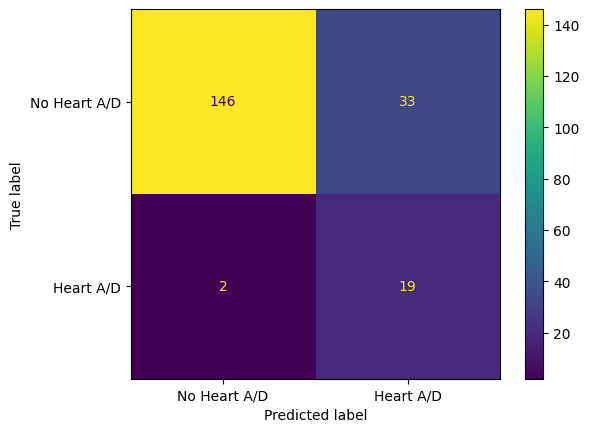

/tmp/ipykernel_2390733/3510064116.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.1, 1, 1])


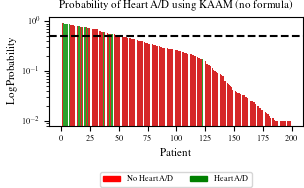

In [38]:
print("########### KAAM model on Heart Failure Clinical Data ###########")

# Load data
args = get_config('explainability')
args['datasets'] = ['heart']
create_results_folder(args['results_folder'], args)
x_train, x_test, y_train, y_test = load_data(args['datasets'][0], args)
results_folder = args['results_folder'] + os.sep + args['datasets'][0] + os.sep + 'use_case' + os.sep
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

print("\nData loaded:")
print(f"Number of train / test patients: {len(x_train)} / {len(x_test)}")
print(f"Number of features per patient: {len(x_train.columns)}")
print(f"Proportion of patients with the positive outcome in the train set: {y_train.sum() / len(y_train):.2f}")
print(f"Proportion of patients with the positive outcome in the test set: {y_test.sum() / len(y_test):.2f}")

### Train KAN model
print("\nTraining KAAM model...")
model = Kan_model(hidden_dim=0,
                  grid=3,
                  k=5,
                  lamb=0.01,
                  lamb_entropy=0.1,
                  lr=0.001,
                  weight=True,
                  sparse_init=False,
                  mult_kan=False,
                  seed=0,
                  batch_size=-1,
                  steps=10000,
                  early_stop=True)

results = model.run_model(x_train.to_numpy(), x_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy())

### Validate model
print("\nValidating KAAM model...")
metrics_df = pd.DataFrame(get_bootstrap_metrics(np.squeeze(y_test.to_numpy()), results['y_pred'], results['y_pred_proba'][:, 1]),
                          index=['Accuracy', 'AUC', 'F1', 'Precision', 'Recall'],
                          columns=['Test'])
show_performance_results(y_test,
                         results['y_pred'],
                         results['y_pred_proba'][:, 1],
                         metrics_df,
                         'Test results using KAAM',
                         'Probability of Heart A/D using KAAM (no formula)',
                         results_folder)

### Now that we have a trained KAN model, we can obtain an approximation of the formula learned by the model, and validate it. ###

fixing (0,0,0) with x, r2=0.9999841451644897, c=1
fixing (0,0,1) with x, r2=0.9999741911888123, c=1
fixing (0,1,0) with x, r2=1.0000008344650269, c=1
fixing (0,1,1) with x, r2=1.0000007152557373, c=1
fixing (0,2,0) with 1/x^2, r2=1.000001311302185, c=2
fixing (0,2,1) with exp, r2=0.9999995231628418, c=2
fixing (0,3,0) with 0, r2=0.0, c=0
fixing (0,3,1) with 0, r2=0.0, c=0
fixing (0,4,0) with x, r2=1.0000008344650269, c=1
fixing (0,4,1) with x, r2=0.9999170303344727, c=1
fixing (0,5,0) with x, r2=1.0000011920928955, c=1
fixing (0,5,1) with x, r2=1.000001072883606, c=1
fixing (0,6,0) with exp, r2=1.0000009536743164, c=2
fixing (0,6,1) with x^2, r2=1.0000007152557373, c=2
fixing (0,7,0) with x, r2=0.9999540448188782, c=1
fixing (0,7,1) with 1/x^2, r2=1.0000008344650269, c=2
fixing (0,8,0) with 1/x, r2=1.0000008344650269, c=2
fixing (0,8,1) with 1/x^2, r2=1.0000009536743164, c=2
fixing (0,9,0) with exp, r2=1.0000009536743164, c=2
fixing (0,9,1) with exp, r2=1.0000008344650269, c=2
fixing (

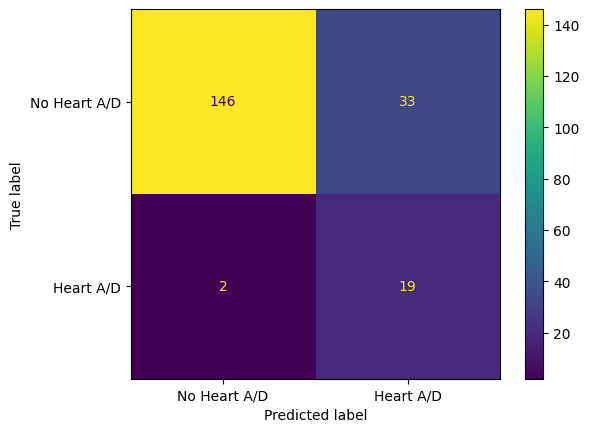

/tmp/ipykernel_2390733/3510064116.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.1, 1, 1])


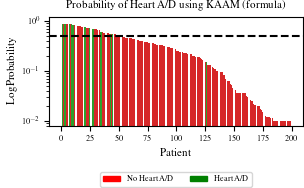

In [39]:
### FORMULA APPROXIMATION ###
## Obtain an approximation of the formula obtained by the KAN model
n_digit = 2  # Number of digits to round the formula to
model.model(model.dataset['train_input'])  # The forward pass is required to adequately obtain the formula
model.model.auto_symbolic()
formula = model.model.symbolic_formula()[0]
formula = [ex_round(f, n_digit) for f in formula]
logit_formula = formula[1] - formula[0]

# In the delta_formula, replace x_i by its name
for i, col in enumerate(x_train.columns):
    logit_formula = logit_formula.subs(sympy.symbols(f'x_{i + 1}'), sympy.symbols(col))

# Print the formula
print("Logit formula:")
print(sympy.latex(logit_formula))

## Validate the model using the approximated formula
# We note that the metrics are similar (i.e., the formula does not introduce a significant decrease in metrics)
y_pred = model.predict(x_test.to_numpy())
y_pred_proba = model.predict_proba(x_test.to_numpy())[:, 1]
metrics_df['Formula'] = get_bootstrap_metrics(np.squeeze(y_test.to_numpy()), y_pred, y_pred_proba)
show_performance_results(y_test,
                         y_pred,
                         y_pred_proba,
                         metrics_df,
                         'Test results using KAAM with formula',
                         'Probability of Heart A/D using KAAM (formula)',
                         results_folder)

### Now that we have the formula, we can obtain the delta matrix, which is key for the interpretability of the model ###

Test results using KAAM's delta matrix
                          Test              Formula                Delta
Accuracy   0.824 (0.823,0.826)  0.825 (0.823,0.827)  0.851 (0.849,0.852)
AUC        0.914 (0.912,0.915)  0.911 (0.909,0.913)  0.914 (0.912,0.916)
F1          0.515 (0.511,0.52)  0.517 (0.512,0.521)  0.558 (0.553,0.562)
Precision  0.363 (0.359,0.367)   0.366 (0.361,0.37)  0.407 (0.402,0.411)
Recall     0.907 (0.903,0.911)  0.902 (0.898,0.907)   0.906 (0.901,0.91)


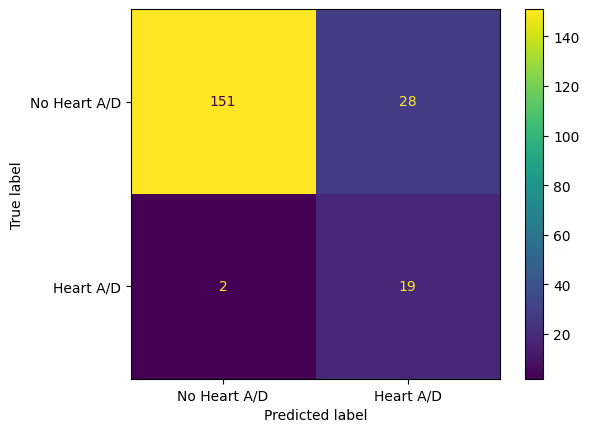

/tmp/ipykernel_2390733/3510064116.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.1, 1, 1])


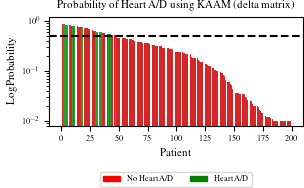

In [40]:
##### DELTA MATRIX #####
## Obtain the delta matrix, key for the interpretability of the model
delta_train = np.zeros((x_train.shape[0], x_train.shape[1] + 1))
for i in range(x_train.shape[0]):  # For each patient
    for fs in logit_formula.args:
        formula_sum_term = deepcopy(fs)
        if isinstance(formula_sum_term, sympy.Float):  # We have a constant!
            delta_train[i , -1] = float(formula_sum_term)
        else: # Since it is a KAAM, it depends on a single variable
            assert len(formula_sum_term.free_symbols) == 1
            variable_in_the_expresion = list(formula_sum_term.free_symbols)[0]
            variable_index = x_train.columns.get_loc(str(variable_in_the_expresion))
            delta_train[i, variable_index] += float(formula_sum_term.subs(variable_in_the_expresion, x_train.iloc[i, variable_index]))


delta_test = np.zeros((x_test.shape[0], x_test.shape[1] + 1))
for i in range(x_test.shape[0]):  # For each patient
    for fs in logit_formula.args:
        formula_sum_term = deepcopy(fs)
        if isinstance(formula_sum_term, sympy.Float):  # We have a constant!
            delta_test[i , -1] = float(formula_sum_term)
        else: # Since it is a KAAM, it depends on a single variable
            assert len(formula_sum_term.free_symbols) == 1
            variable_in_the_expresion = list(formula_sum_term.free_symbols)[0]
            variable_index = x_test.columns.get_loc(str(variable_in_the_expresion))
            delta_test[i, variable_index] += float(formula_sum_term.subs(variable_in_the_expresion, x_test.iloc[i, variable_index]))

## Revalidate with the delta matrix
y_delta_pred_proba = 1. / (1 + np.exp(-delta_test.sum(axis=1)))
y_delta_pred = (y_delta_pred_proba > 0.5).astype(int)
metrics_df['Delta'] = get_bootstrap_metrics(np.squeeze(y_test.to_numpy()), y_delta_pred, y_delta_pred_proba)
show_performance_results(y_test,
                         y_delta_pred,
                         y_delta_pred_proba,
                         metrics_df,
                         'Test results using KAAM\'s delta matrix',
                         'Probability of Heart A/D using KAAM (delta matrix)',
                         results_folder)
# Note that small differences may happen due to the fact that we limit the number of decimals in the formula constants!

### INTERPRETABILITY TOOLS ###
We compare the interpretability tools provided by the KAAM model with SHAP values for a black-box model.

/tmp/ipykernel_2390733/1008799201.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


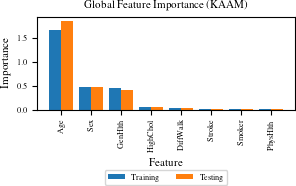

PermutationExplainer explainer: 201it [00:14,  4.44it/s]                         
/tmp/ipykernel_2390733/1008799201.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test)


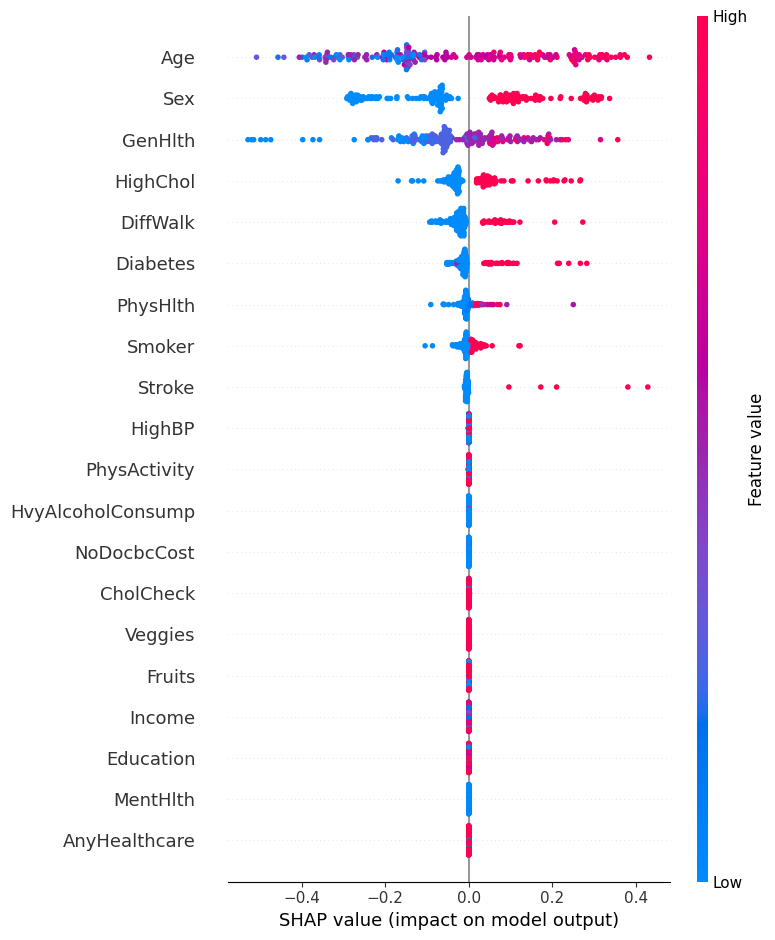

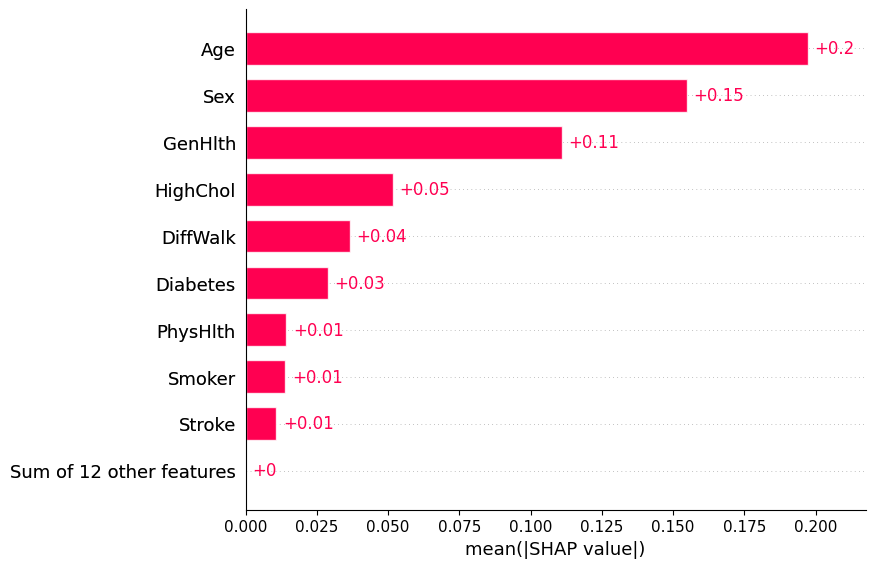

In [41]:
### INTERPRETABILITY ###
# Global interpretability: use the KAN model to obtain the global importance of each feature by using the var of the delta matrix
global_importance_train = np.var(delta_train, axis=0)
global_importance_test = np.var(delta_test, axis=0)

# Sort variables by importance
variable_names = x_train.columns.tolist() + ['Constant']
sorted_idx_train = np.argsort(global_importance_train)[::-1]

# Keep only variables with non-zero importance
num_of_zero_var = (global_importance_train < 1e-6).sum()
sorted_idx_train = sorted_idx_train[:-num_of_zero_var]

# Plot the global importance
x = np.arange(len(sorted_idx_train))
width = 0.4
with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
    plt.bar(x - width / 2, global_importance_train[sorted_idx_train], label='Training', width=width, color='tab:blue')
    plt.bar(x + width / 2, global_importance_test[sorted_idx_train], label='Testing', width=width, color='tab:orange')
    plt.title('Global Feature Importance (KAAM)')
    plt.xticks(range(len(sorted_idx_train)), np.array(variable_names)[sorted_idx_train], rotation=90)
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.85), ncol=2)  # Note: this can be uncommented, but may clutter the plot
    plt.rcParams.update(bundles.icml2024(usetex=False))
    plt.savefig(results_folder + 'global_feat_imp_kaam.pdf', dpi=300)
    plt.show()
    plt.close()

## Compare with SHAP values for a black-box model
# Train the SHAP explainer
explainer = shap.Explainer(model.predict, x_train)
shap_values = explainer(x_test)

# Plot the SHAP values and save the plots
shap.summary_plot(shap_values, x_test)
shap.plots.bar(shap_values)

## USE CASE: analyze individual patients with the interpretability tools provided by KAAM ##

Imagine that the clinician receives a **patient with low risk** (PATIENT A), as assessed by the model: our tools allow checking with a higher security that it is indeed a low-risk patient, as there are several patients in the historical records with a similar profile.

However, this dataset is highly unbalanced: what if the model predicts as **high-risk a patient that is actually low-risk** (PATIENT B)? We can also check this with our tools. Namely, note that the closest patients in the dataset are mostly low-risk patients, which may help the clinicians to decide on the patient


In [42]:
def get_closest_patients(tr_x, tr_y, tr_d, patient_d, index_feats, patient_inf, n_closest):
    dists = np.linalg.norm(tr_d - patient_d.values, axis=1)
    idx_closest = np.argsort(dists)[:n_closest].tolist()
    pred_prob = (1 / (1 + np.exp(-tr_d[idx_closest].sum(axis=1))))
    real_label = tr_y.iloc[idx_closest].values
    closest_data = tr_x.iloc[idx_closest].values[:, index_feats]
    closest_data = np.concatenate((closest_data, pred_prob[:, None], real_label[:, None]), axis=1)
    closest_data = np.vstack((patient_inf[None, :], closest_data)) # Add the current patient as the first row
    new_df = pd.DataFrame(closest_data, columns=np.array(tr_x.columns.tolist())[index_feats].tolist() + ['pred_prob', 'real_label'])
    new_df = new_df.map(lambda x: round(x, 3) if isinstance(x, float) else x)  # Limit all new_df values to having 3 decimal numbers at most
    new_df.index = ['Test'] + ['Train patient ' + str(j) for j in idx_closest]  # Add the index to the new_df
    return new_df, idx_closest

def get_radar_plot(tr_d, patient_d, patient_pred_prob, n_feats, idx_vars, cols_vars, y, n_closest, closest_idx, patient_title, c):
    theta = radar_factory(n_feats, frame='polygon')
    cohort_avg_prob = 1 / (1 + np.exp(-tr_d.mean(axis=0).sum())) * np.ones(len(cols_vars))
    title = (f"Test Patient \n Predicted: {patient_pred_prob:.3f} | True: {y} | Average: {cohort_avg_prob[0]:.3f}")

    with plt.rc_context({**bundles.icml2024(column='half', ncols=1, nrows=1, usetex=True)}):
        fig, ax = plt.subplots(subplot_kw=dict(projection='radar'))
        ax.set_title(title)
        # Plot the average of all train patients
        _ = ax.plot(theta, cohort_avg_prob, label='Average', color=c[0], linewidth=0.5)
        ax.fill(theta, cohort_avg_prob, alpha=0.1, color=c[0])
        # Prepare for individual patient plotting
        avg_delta = tr_d.mean(axis=0)[None, :]
        avg_matrix = np.repeat(avg_delta, tr_d.shape[1], axis=0)
        # Plot the closest patients
        for j in range(n_closest):
            np.fill_diagonal(avg_matrix, tr_d[closest_idx[j]])
            pat_proba = 1 / (1 + np.exp(-avg_matrix.sum(axis=1)))
            _ = ax.plot(theta, pat_proba[idx_vars], label=f'Closest patient', color='#2ca02c', alpha=0.9,
                        linewidth=1.25)
            ax.fill(theta, pat_proba[idx_vars], alpha=0.1, color=c[1])
        # Plot the current patient
        np.fill_diagonal(avg_matrix, patient_d.values)
        pat_proba = 1 / (1 + np.exp(-avg_matrix.sum(axis=1)))
        _ = ax.plot(theta, pat_proba[idx_vars], label='Test patient', color=c[2], alpha=0.7, linewidth=1.15,
                    linestyle='dashed')
        ax.fill(theta, pat_proba[idx_vars], alpha=0.1, color=c[2])
        ax.set_varlabels(cols_vars, fontsize=6)
        plt.legend(loc='lower center',
                   bbox_to_anchor=(0.5, -0.45),
                   ncol=3)  # Note: this can be uncommented, but may clutter the plot
        plt.savefig(results_folder + f'{patient_title}_radar_patient_pred_{y}_feat_{n_feats}_closest_{n_closest}.pdf', dpi=300)
        plt.show()
        plt.close()


def get_curves(tr_d, patient_d, cols, n_feats, cols_vars, n_closest, closest_idx, patient_x, patient_title, c):
    tr_d_df = pd.DataFrame(tr_d, columns=cols)
    with plt.rc_context({**bundles.icml2024(column='half', ncols=1, nrows=1, usetex=True)}):
        fig, axs = plt.subplots(n_feats + 1, 1, figsize=(6, 1.6 * (n_feats + 1)))
        x_vals = np.arange(tr_d.sum(axis=1).min(), tr_d.sum(axis=1).max(), 0.01)
        theor_proba = 1 / (1 + np.exp(-x_vals))
        patient_pred_prob = (1 / (1 + np.exp(-tr_d[closest_idx].sum(axis=1))))  # Average probability (i.e., "average patient")
        axs[0].plot(x_vals, theor_proba, c[0], alpha=0.2, linewidth=0.8)
        for idj, feat_name in enumerate(cols_vars):
            if idj < n_feats:  # Only plot the first n_feats features
                j = idj + 1  # The first plot is already used for the theoretical curve
                idxs = np.unique(x_train[feat_name].values, return_index=True)[
                    1]  # Keep only unique values of x_test[feat_name]
                axs[j].plot(x_train[feat_name].values[idxs], tr_d_df[feat_name].values[idxs], color=c[0], linewidth=0.8)
                axs[j].scatter(x_train[feat_name].values[idxs], tr_d_df[feat_name].values[idxs], color=c[0], alpha=0.1)
                for jj in range(n_closest):
                    axs[j].scatter(x_train.iloc[closest_idx[jj]][feat_name], tr_d_df.iloc[closest_idx[jj]][feat_name],
                                   color=c[1], alpha=0.8, s=30, marker='o')
                axs[j].scatter(patient_x[feat_name], patient_d[feat_name], color=c[2], s=70, marker='x')
                axs[j].set_ylabel(feat_name)
        axs[0].scatter(patient_d.values.sum(), patient_pred_prob, color=c[2], marker='x', s=70)
        # axs[0].set_xlabel('Logit')
        axs[0].set_ylabel('Probability')
        axs[0].set_title(f'Patient results')
        # Add legend
        red_patch = mpatches.Patch(color=c[2], label='Test patient')
        green_patch = mpatches.Patch(color=c[1], label='Closest patient')
        blue_patch = mpatches.Patch(color=c[0], label='Train patients')
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        axs[-1].legend(handles=[red_patch, green_patch, blue_patch], loc='lower center',
                       bbox_to_anchor=(0.5, -0.6), ncol=3)
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(results_folder + f'{patient_title}_curves_patient_feat_{n_feats}_closest_{n_closest}.pdf', dpi=300)
        plt.show()
        plt.close()


def analyze_patient(patient_idx, training_covariates, training_label, training_delta, patient_title, max_feats=10, n_closest=5, max_curves=10, c=['b', 'g', 'r']):
    # Specific patient information
    cols = training_covariates.columns.tolist() + ['Constant']
    patient_delta = pd.DataFrame(delta_test[patient_idx].reshape([1, len(cols)]), columns=cols)
    x = x_test.iloc[patient_idx]
    y = int(y_test.iloc[patient_idx])
    patient_predicted_prob = 1 / (1 + np.exp(-patient_delta.values.sum()))

    # Find the closest patients in the training set
    variances = np.var(training_delta, axis=0)
    idx_vars = np.argsort(variances)[::-1]
    num_of_zero_var = (variances < 1e-6).sum()
    idx_vars = idx_vars[:-num_of_zero_var]
    if training_delta.shape[1] > max_feats:
        idx_vars = idx_vars[:max_feats]
    patient_info = np.concatenate((x[idx_vars].values, [patient_predicted_prob, y]))
    closest_patients_df, closest_patients_idx = get_closest_patients(training_covariates, training_label, training_delta, patient_delta, idx_vars, patient_info, n_closest)
    print("\nClosest patients in the training set:")
    print(closest_patients_df)

    # Plot the radar chart (show only high-variance features)
    idx_vars = idx_vars[::-1]
    cols_vars = [cols[i] for i in idx_vars.tolist()]   # Change the order of idx_vars and cols_vars to have the importance in clockwise order in the plot
    n_feats = min(max_feats, len(cols_vars))  # Number of features to show in the radar plot
    if n_feats >= 3:  # We need at least 3 features to plot a proper radar plot
        get_radar_plot(training_delta, patient_delta, patient_predicted_prob, n_feats, idx_vars, cols_vars, y, n_closest, closest_patients_idx, patient_title, c)

    # Curves plot: show only the ones that do matter!!
    idx_vars = idx_vars[::-1]  #  Revert again the order to have the right plot order
    cols_vars = [cols[i] for i in idx_vars.tolist()]
    n_feats = min(len(cols_vars), max_curves)  # Number of features to show in the curves plot
    if n_feats > 0:  # There is something to show
        get_curves(training_delta, patient_delta, cols, n_feats, cols_vars, n_closest, closest_patients_idx, x, patient_title, c)



def get_comparison_radar_plot(tr_d, n_feats, cols_vars, idx_vars, patient_a_d, y_a, patient_a_pred_prob, patient_b_d, y_b, patient_b_pred_prob):
    theta = radar_factory(n_feats, frame='polygon')
    cohort_avg_prob = 1 / (1 + np.exp(-tr_d.mean(axis=0).sum())) * np.ones(len(cols_vars))
    title = (f"Test Patient A Predicted: {patient_a_pred_prob:.3f} | True: {y_a} | Average: {cohort_avg_prob[0]:.3f}\n"
             f"Test Patient B Predicted: {patient_b_pred_prob:.3f} | True: {y_b} | Average: {cohort_avg_prob[0]:.3f}")

    with plt.rc_context({**bundles.icml2024(column='half', ncols=1, nrows=1, usetex=True)}):
        fig, ax = plt.subplots(subplot_kw=dict(projection='radar'))
        ax.set_title(title)
        # Plot the average of all train patients
        _ = ax.plot(theta, cohort_avg_prob, label='Average', color='tab:blue', linewidth=0.5)
        ax.fill(theta, cohort_avg_prob, alpha=0.1, color='tab:blue')
        # Prepare for individual patient plotting
        avg_delta = tr_d.mean(axis=0)[None, :]
        avg_matrix = np.repeat(avg_delta, tr_d.shape[1], axis=0)
        # Plot patient A
        np.fill_diagonal(avg_matrix, patient_a_d.values)
        pat_proba = 1 / (1 + np.exp(-avg_matrix.sum(axis=1)))
        _ = ax.plot(theta, pat_proba[idx_vars],
                    label='Patient A',
                    color='tab:pink', alpha=0.7, linewidth=1.15, linestyle='dashed')
        ax.fill(theta, pat_proba[idx_vars], alpha=0.1, color='tab:pink')
        # Plot patient B
        np.fill_diagonal(avg_matrix, patient_b_d.values)
        pat_proba = 1 / (1 + np.exp(-avg_matrix.sum(axis=1)))
        _ = ax.plot(theta, pat_proba[idx_vars],
                    label='Patient B',
                    color='tab:purple', alpha=0.7, linewidth=1.15, linestyle='dashed')
        ax.fill(theta, pat_proba[idx_vars], alpha=0.1, color='tab:purple')
        ax.set_varlabels(cols_vars, fontsize=6)
        plt.legend(loc='lower center',
                   bbox_to_anchor=(0.5, -0.45),
                   ncol=3)  # Note: this can be uncommented, but may clutter the plot
        plt.savefig(results_folder + f'comparison_radar_patients.pdf', dpi=300)
        plt.show()
        plt.close()

def get_comparison_curves(tr_d, cols, n_feats, cols_vars, patient_a, patient_b, patient_pred_prob_a, patient_pred_prob_b, patient_a_d, patient_b_d):
    tr_d_df = pd.DataFrame(tr_d, columns=cols)
    with plt.rc_context({**bundles.icml2024(column='half', ncols=1, nrows=1, usetex=True)}):
        fig, axs = plt.subplots(n_feats + 1, 1, figsize=(4, 1.4 * (n_feats + 1)))
        x_vals = np.arange(tr_d.sum(axis=1).min(), tr_d.sum(axis=1).max(), 0.01)
        theor_proba = 1 / (1 + np.exp(-x_vals))
        axs[0].plot(x_vals, theor_proba, 'tab:blue', alpha=0.2, linewidth=0.8)
        for idj, feat_name in enumerate(cols_vars):
            if idj < n_feats:  # Only plot the first n_feats features
                j = idj + 1  # The first plot is already used for the theoretical curve
                idxs = np.unique(x_train[feat_name].values, return_index=True)[1]  # Keep only unique values of x_test[feat_name]
                axs[j].plot(x_train[feat_name].values[idxs], tr_d_df[feat_name].values[idxs], color='tab:blue', linewidth=0.8)
                axs[j].scatter(x_train[feat_name].values[idxs], tr_d_df[feat_name].values[idxs], color='tab:blue', alpha=0.1)

                axs[j].scatter(patient_a[feat_name], patient_a_d[feat_name], color='tab:pink', marker='x', s=45)
                axs[j].scatter(patient_b[feat_name], patient_b_d[feat_name], color='tab:purple', marker='o', s=20)

                axs[j].set_ylabel('Contribution', fontsize=10)
                axs[j].set_xlabel(feat_name, fontsize=10)

        axs[0].scatter(patient_a_d.values.sum(), patient_pred_prob_a, color='tab:pink', marker='x', s=45)
        axs[0].scatter(patient_b_d.values.sum(), patient_pred_prob_b, color='tab:purple', marker='o', s=20)
        axs[0].set_ylabel('Probability', fontsize=10)
        axs[0].set_xlabel('Logit', fontsize=10)
        axs[0].set_title(f'Patients Results', fontsize=12)
        # Add legend
        pink_patch = mpatches.Patch(color='tab:pink', label='Patient A')
        purple_patch = mpatches.Patch(color='tab:purple', label='Patient B')
        blue_patch = mpatches.Patch(color='tab:blue', label='Train patients')
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        axs[-1].legend(handles=[blue_patch, pink_patch, purple_patch], loc='lower center',
                       bbox_to_anchor=(0.5, -0.9), ncol=3, fontsize=10)
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(results_folder + f'comparison_curves_patients.pdf', dpi=300)
        plt.show()
        plt.close()


def compare_patients(patient_a_idx, patient_b_idx, tr_x, tr_y, tr_d, max_feats=10, max_curves=10):
    # Specific patient information --> PATIENT A
    cols = tr_x.columns.tolist() + ['Constant']
    patient_delta_a = pd.DataFrame(delta_test[patient_a_idx].reshape([1, len(cols)]), columns=cols)
    x_a = x_test.iloc[patient_a_idx]
    y_a = int(y_test.iloc[patient_a_idx])
    patient_predicted_prob_a = 1 / (1 + np.exp(-patient_delta_a.values.sum()))

    # Specific patient information --> PATIENT B
    patient_delta_b = pd.DataFrame(delta_test[patient_b_idx].reshape([1, len(cols)]), columns=cols)
    x_b = x_test.iloc[patient_b_idx]
    y_b = int(y_test.iloc[patient_b_idx])
    patient_predicted_prob_b = 1 / (1 + np.exp(-patient_delta_b.values.sum()))

    # Find the closest patients in the training set
    variances = np.var(tr_d, axis=0)
    idx_vars = np.argsort(variances)[::-1]
    num_of_zero_var = (variances < 1e-6).sum()
    idx_vars = idx_vars[:-num_of_zero_var]
    if tr_d.shape[1] > max_feats:
        idx_vars = idx_vars[:max_feats]

    # Plot the radar chart (show only high-variance features)
    idx_vars = idx_vars[::-1]
    cols_vars = [cols[i] for i in
                 idx_vars.tolist()]  # Change the order of idx_vars and cols_vars to have the importance in clockwise order in the plot
    n_feats = min(max_feats, len(cols_vars))  # Number of features to show in the radar plot
    if n_feats >= 3:  # We need at least 3 features to plot a proper radar plot
        get_comparison_radar_plot(tr_d, n_feats, cols_vars, idx_vars, patient_delta_a, y_a, patient_predicted_prob_a, patient_delta_b, y_b, patient_predicted_prob_b)

    # Curves plot: show only the ones that do matter!!
    idx_vars = idx_vars[::-1]  # Revert again the order to have the right plot order
    cols_vars = [cols[i] for i in idx_vars.tolist()]
    n_feats = min(len(cols_vars), max_curves)  # Number of features to show in the curves plot
    if n_feats > 0:  # There is something to show
        get_comparison_curves(tr_d, cols, n_feats, cols_vars, x_a, x_b, patient_predicted_prob_a, patient_predicted_prob_b, patient_delta_a, patient_delta_b)




Analyzing PATIENT A (true negative). Index in test set: 0

Closest patients in the training set:
                    Age  Sex  GenHlth  HighChol  DiffWalk  Stroke  Smoker  \
Test             -0.011  0.0    0.457       1.0       0.0     0.0     0.0   
Train patient 33 -0.011  0.0    0.457       1.0       0.0     0.0     0.0   

                  PhysHlth  pred_prob  real_label  
Test                -0.487      0.242         0.0  
Train patient 33    -0.028      0.243         0.0  


/tmp/ipykernel_2390733/3679153897.py:104: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  patient_info = np.concatenate((x[idx_vars].values, [patient_predicted_prob, y]))


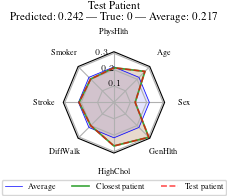

/tmp/ipykernel_2390733/3679153897.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


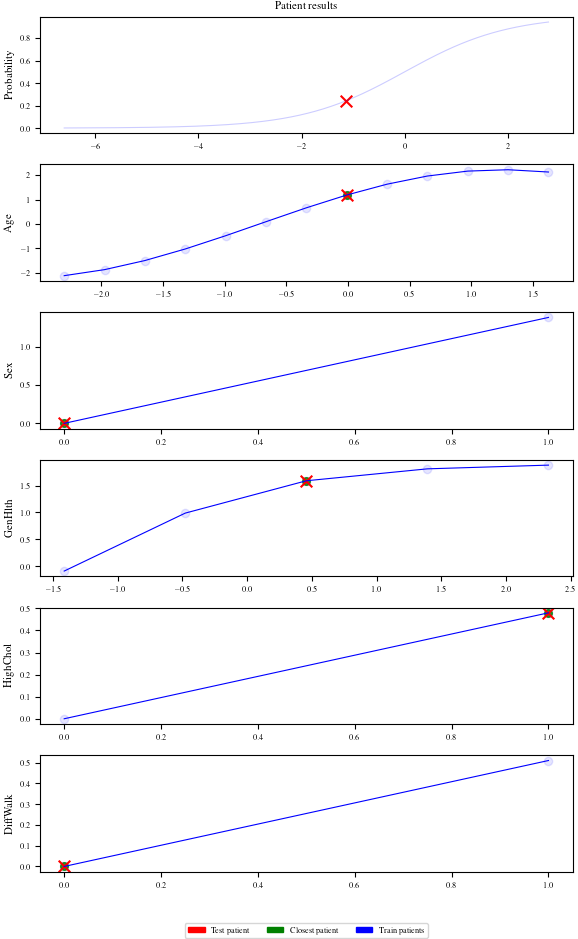

In [43]:
# PATIENT A
# Find a true negative patient
true_negatives = np.where((y_test == 0) & (y_delta_pred == 0))[0]
patient_a_idx = true_negatives[0]
print("\nAnalyzing PATIENT A (true negative). Index in test set:", patient_a_idx)
analyze_patient(patient_a_idx, x_train, y_train, delta_train, 'patient_A', n_closest=1, max_feats=args['max_atribs_radar'], max_curves=args['max_plot_curves'])


Closest patients in the training set:
                     Age  Sex  GenHlth  HighChol  DiffWalk  Stroke  Smoker  \
Test               0.972  1.0    0.457       1.0       0.0     0.0     1.0   
Train patient 253  0.972  1.0    0.457       1.0       0.0     0.0     1.0   

                   PhysHlth  pred_prob  real_label  
Test                 -0.487      0.807         0.0  
Train patient 253    -0.487      0.807         0.0  


/tmp/ipykernel_2390733/3679153897.py:104: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  patient_info = np.concatenate((x[idx_vars].values, [patient_predicted_prob, y]))


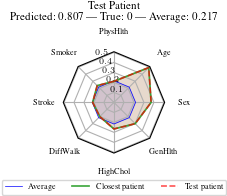

/tmp/ipykernel_2390733/3679153897.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


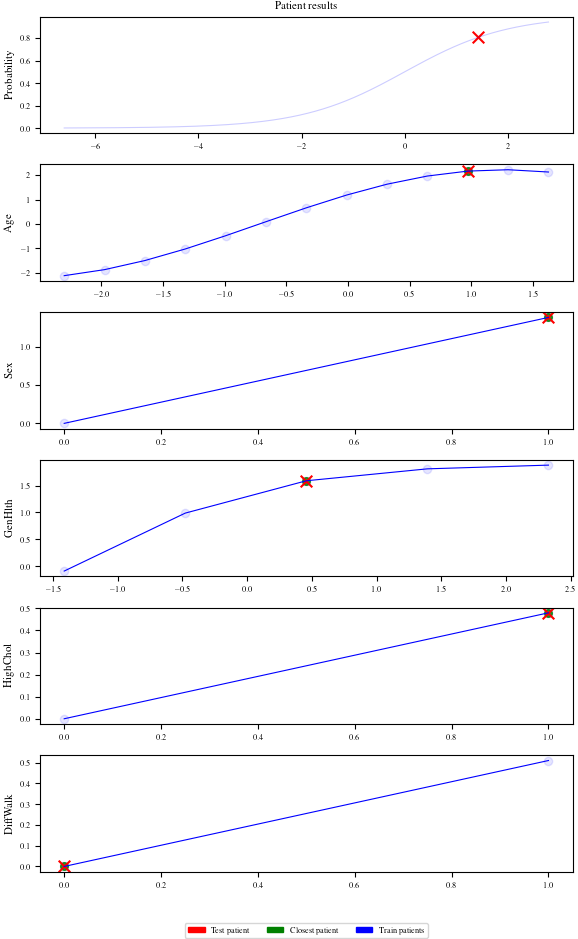

In [44]:
# PATIENT B
# Find a false positive patient
false_positives = np.where((y_test == 0) & (y_delta_pred == 1))[0]
patient_b_idx = false_positives[0]
analyze_patient(patient_b_idx, x_train, y_train, delta_train, 'patient_B', n_closest=1, max_feats=args['max_atribs_radar'], max_curves=args['max_plot_curves'], c=['b', 'g', 'r'])

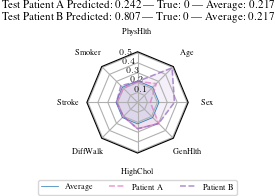

/tmp/ipykernel_2390733/3679153897.py:199: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.05, 1, 1])


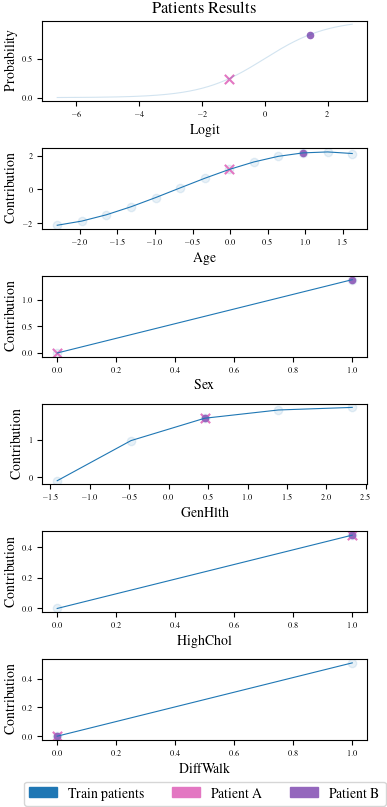

In [45]:
# Let's compare both patients
compare_patients(patient_a_idx, patient_b_idx, x_train, y_train, delta_train, max_feats=args['max_atribs_radar'], max_curves=args['max_plot_curves'])

# **INTERACTIVE INTERFACE**
We can also do this in an interactive way, so that a clinician can do an interactive study of a patient. Note that we use the standardizes values, for an actual clinical application, these values would not be standardized, but the actual values of the patient

In [46]:
def interactive_pat(DiffWalk, HighChol, Sex, Smoker, Stroke, Diabetes, PhysHlth, GenHlth, Age):
    x_patient = pd.DataFrame(np.zeros((1, len(variable_names)), dtype=np.float32), columns=variable_names)
    x_patient['DiffWalk'] = DiffWalk
    x_patient['HighChol'] = HighChol
    x_patient['Sex'] = Sex
    x_patient['Smoker'] = Smoker
    x_patient['Stroke'] = Stroke
    x_patient['Diabetes'] = Diabetes
    x_patient['PhysHlth'] = PhysHlth
    x_patient['GenHlth'] = GenHlth
    x_patient['Age'] = Age
    # We provide here a formula example: different seeds and/or runs may provide slightly different formulae
    delta_patient = pd.DataFrame(np.zeros((1, len(variable_names)), dtype=np.float32), columns=variable_names)
    delta_patient['DiffWalk'] = 0.52 * DiffWalk
    delta_patient['HighChol'] = 0.49 * HighChol
    delta_patient['Sex'] = 1.4 * Sex
    delta_patient['Smoker'] = 0.21 * Smoker
    delta_patient['Stroke'] = 0.82 * Stroke
    delta_patient['Diabetes'] = 0.09 * (0.51 - Diabetes)**2
    delta_patient['PhysHlth'] = 0.13 * np.sin(1.43 * PhysHlth - 7.45)
    delta_patient['Age'] = - 1.15 * np.cos(0.79 * Age + 2.18) - 1.09 * np.cos(0.8 * Age + 8.41 )
    delta_patient['GenHlth'] = 1.18 * np.tanh(0.63 * GenHlth + 0.92 ) + 0.76 * np.tanh(0.7 * GenHlth + 0.87 )
    delta_patient['Constant'] = - 4.32

    analyze_patient(delta_patient, x_patient.iloc[0], -1)

Age = widgets.FloatSlider(value=0.0, min=-4, max=4.0, step=0.1, description='Age', disabled=False, continuous_update=False, orientation='horizontal', readout=True,readout_format='.1f')
Sex = widgets.Dropdown(options=[0, 1], value=0, description='Sex')
GenHlth = widgets.Dropdown(options=[-1.41, -0.48 ,  0.46, 1.39, 2.33], value=0.46, description='GenHlth')
HighChol = widgets.Dropdown(options=[0, 1], value=0, description='HighChol')
DiffWalk = widgets.Dropdown(options=[0, 1], value=0, description='DiffWalk')
Smoker = widgets.Dropdown(options=[0, 1], value=0, description='Smoker')
Stroke = widgets.Dropdown(options=[0, 1], value=0, description='Stroke')
PhysHlth = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1, description='PhysHlth', disabled=False, continuous_update=False, orientation='horizontal', readout=True,readout_format='.1f')
Diabetes = widgets.Dropdown(options=[0, 1, 2], value=0, description='Diabetes')

f = lambda Age, Sex, GenHlth, HighChol, DiffWalk, Smoker, Stroke, PhysHlth, Diabetes: interactive_pat(DiffWalk, HighChol, Sex, Smoker, Stroke, Diabetes, PhysHlth, GenHlth, Age)

widgets.interactive(f, Age=Age, Sex=Sex, GenHlth=GenHlth, HighChol=HighChol, DiffWalk=DiffWalk, Smoker=Smoker, Stroke=Stroke, PhysHlth=PhysHlth, Diabetes=Diabetes)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Age', max=4.0, min=-4.0, re…